# Лабораторная работа №1. Разведочный анализ данных

**Датасет:** Car Price Prediction  
**Тип задачи:** регрессия  
**Целевая переменная:** `Selling_Price`

Цель работы — подготовить данные для дальнейшего машинного обучения:
проверить структуру и качество данных, провести очистку, исследовать признаки,
создать полезный новый признак и сохранить очищенную выборку.

# 1. Загрузка и знакомство с данными

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/car_data.csv")
EDA_DIR = Path(".")
CLEAN_PATH = Path("../data/clean_data.pkl")

df = pd.read_csv(DATA_PATH)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
print("Размер выборки:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nКоличество пропусков:")
print(df.isna().sum())
print("\nКоличество полных дубликатов:", df.duplicated().sum())

Размер выборки: (301, 9)

Типы данных:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Количество пропусков:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Количество полных дубликатов: 2


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


### Типы признаков

**Целевая переменная:** `Selling_Price`.

**Числовые признаки:** `Year`, `Present_Price`, `Driven_kms`, `Owner`.

**Категориальные признаки:** `Car_Name`, `Fuel_Type`, `Selling_type`, `Transmission`.

`Owner` хранится как число, но по смыслу является дискретным признаком.

In [4]:
categorical_cols = ["Car_Name", "Fuel_Type", "Selling_type", "Transmission"]
numeric_cols = ["Year", "Present_Price", "Driven_kms", "Owner"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(15))


Car_Name:
Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
amaze                         7
jazz                          7
eon                           6
sx4                           6
ertiga                        6
Name: count, dtype: int64

Fuel_Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling_type:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


# 2. Очистка данных

In [5]:
# Сохраняем исходное количество строк
n_before = len(df)

# Удаляем полные дубликаты
df = df.drop_duplicates().copy()

print("Удалено дубликатов:", n_before - len(df))
print("Размер после удаления дубликатов:", df.shape)

Удалено дубликатов: 2
Размер после удаления дубликатов: (299, 9)


In [6]:
# Базовая проверка валидности
checks = {
    "Selling_Price <= 0": (df["Selling_Price"] <= 0).sum(),
    "Present_Price <= 0": (df["Present_Price"] <= 0).sum(),
    "Driven_kms < 0": (df["Driven_kms"] < 0).sum(),
    "Owner < 0": (df["Owner"] < 0).sum(),
}
pd.Series(checks)

Selling_Price <= 0    0
Present_Price <= 0    0
Driven_kms < 0        0
Owner < 0             0
dtype: int64

В выборке нет пропусков и нет отрицательных/нулевых значений в основных ценовых признаках.
После удаления полных дубликатов дополнительные строки по этим условиям не удалялись.

Статистические выбросы автоматически не удаляются: большой пробег или высокая цена
могут быть реальными наблюдениями. Удалять такие строки без предметного основания было бы неправильно.

## Создание нового признака

In [7]:
# Относительный возраст: самый новый год в датасете считается возрастом 0
reference_year = df["Year"].max()
df["Car_Age"] = reference_year - df["Year"]

df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


Создан новый признак `Car_Age`. Он показывает, насколько автомобиль старше самого нового
автомобиля в выборке. Такой признак удобнее интерпретировать, чем исходный календарный год:
чем больше `Car_Age`, тем старше автомобиль.

# 3. Анализ признаков для модели

## График 1. Распределение целевой переменной

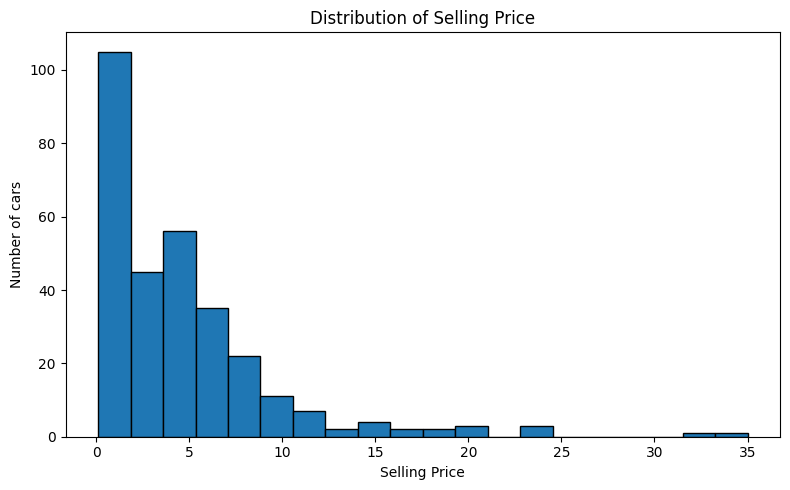

Mean: 4.59
Median: 3.51


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Selling_Price"], bins=20, edgecolor="black")
ax.set_title("Distribution of Selling Price")
ax.set_xlabel("Selling Price")
ax.set_ylabel("Number of cars")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph1_selling_price_distribution.png", dpi=150)
plt.show()

print("Mean:", round(df["Selling_Price"].mean(), 2))
print("Median:", round(df["Selling_Price"].median(), 2))

**Вывод:** распределение `Selling_Price` имеет правую асимметрию.
Среднее значение выше медианы, так как в выборке присутствует небольшое число дорогих автомобилей.
Это важно учитывать при дальнейшем обучении модели.

## График 2. Связь текущей цены и цены продажи

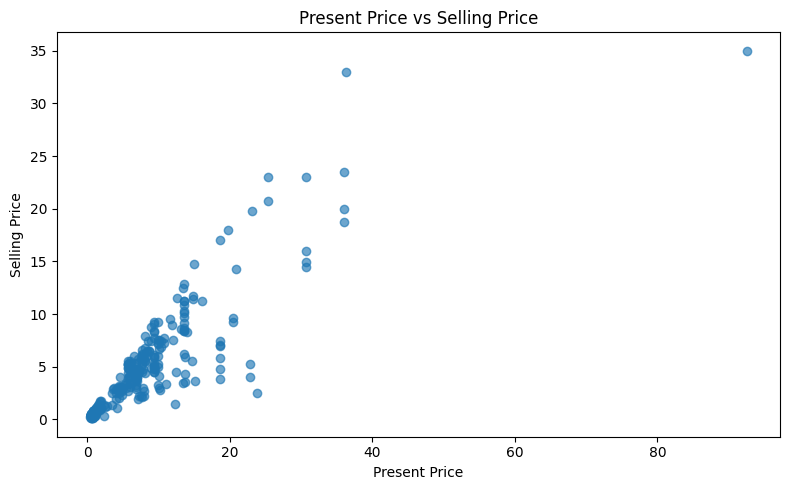

Correlation: 0.876


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Present_Price"], df["Selling_Price"], alpha=0.65)
ax.set_title("Present Price vs Selling Price")
ax.set_xlabel("Present Price")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph2_present_vs_selling.png", dpi=150)
plt.show()

print("Correlation:",
      round(df["Present_Price"].corr(df["Selling_Price"]), 3))

**Вывод:** между `Present_Price` и `Selling_Price` наблюдается сильная положительная связь.
Следовательно, `Present_Price` является одним из наиболее информативных признаков
для будущей модели прогнозирования цены.

## График 3. Цена продажи по типу топлива

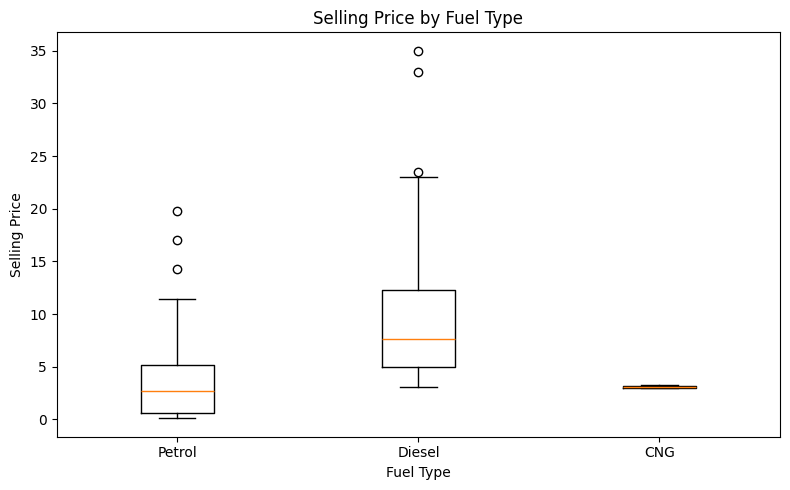

,count,mean,median
Fuel_Type,,,
CNG,2,3.10,3.10
Diesel,58,10.10,7.60
Petrol,239,3.26,2.65


In [10]:
fuel_order = ["Petrol", "Diesel", "CNG"]
fuel_data = [df.loc[df["Fuel_Type"] == x, "Selling_Price"] for x in fuel_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(fuel_data, tick_labels=fuel_order)
ax.set_title("Selling Price by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph3_fuel_type_boxplot.png", dpi=150)
plt.show()

df.groupby("Fuel_Type")["Selling_Price"].agg(["count", "mean", "median"]).round(2)

**Вывод:** в данной выборке дизельные автомобили имеют более высокую типичную цену продажи,
чем бензиновые. Для CNG наблюдений всего два, поэтому по этой категории нельзя делать
устойчивые выводы. Различия нельзя интерпретировать как чистый причинный эффект топлива,
поскольку группы отличаются и по другим характеристикам автомобилей.

## График 4. Цена продажи по типу коробки передач

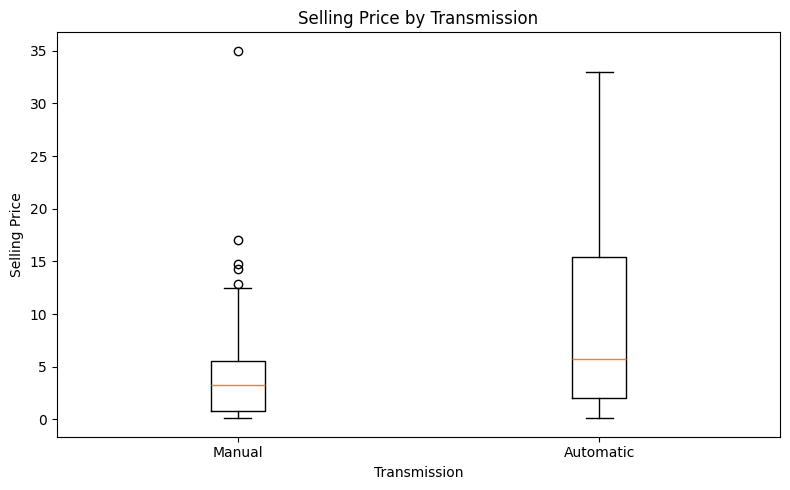

,count,mean,median
Transmission,,,
Automatic,39,9.07,5.75
Manual,260,3.92,3.25


In [11]:
trans_order = ["Manual", "Automatic"]
trans_data = [df.loc[df["Transmission"] == x, "Selling_Price"] for x in trans_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(trans_data, tick_labels=trans_order)
ax.set_title("Selling Price by Transmission")
ax.set_xlabel("Transmission")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph4_transmission_boxplot.png", dpi=150)
plt.show()

df.groupby("Transmission")["Selling_Price"].agg(["count", "mean", "median"]).round(2)

**Вывод:** медианная цена автомобилей с автоматической коробкой выше, чем у автомобилей
с механической коробкой. Тип трансмиссии может быть полезен как категориальный признак модели.
При этом группа `Automatic` существенно меньше группы `Manual`.

## График 5. Цена по типу продавца

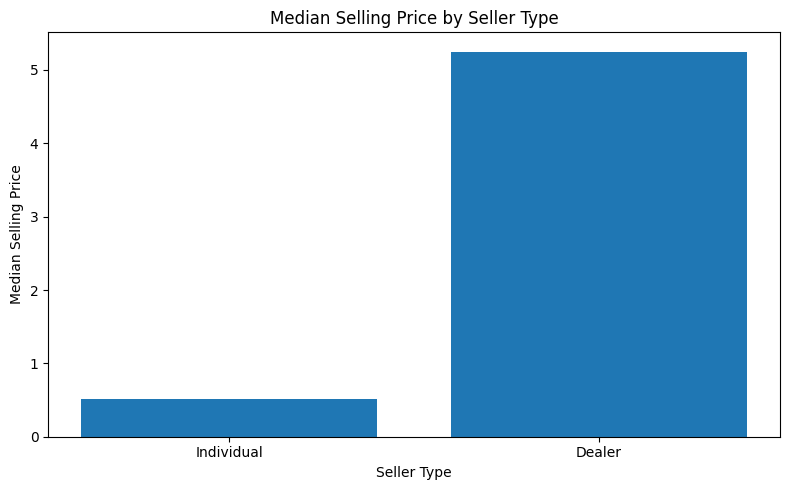

,count,mean,median
Selling_type,,,
Dealer,193,6.63,5.25
Individual,106,0.87,0.52


In [12]:
seller_median = df.groupby("Selling_type")["Selling_Price"].median().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seller_median.index, seller_median.values)
ax.set_title("Median Selling Price by Seller Type")
ax.set_xlabel("Seller Type")
ax.set_ylabel("Median Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph5_seller_type_median.png", dpi=150)
plt.show()

df.groupby("Selling_type")["Selling_Price"].agg(["count", "mean", "median"]).round(2)

**Вывод:** в этой выборке автомобили, продаваемые через `Dealer`, имеют значительно более высокую
медианную цену, чем автомобили категории `Individual`. Это может быть связано с тем,
что состав автомобилей в двух группах различается, поэтому признак полезен для модели,
но сам по себе не доказывает причинного влияния типа продавца на цену.

## График 6. Матрица корреляций

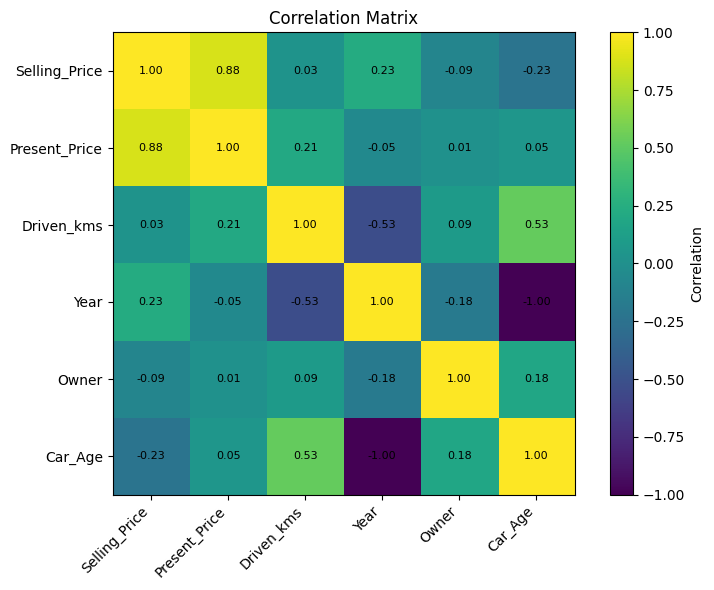

,Selling_Price,Present_Price,Driven_kms,Year,Owner,Car_Age
Selling_Price,1.000,0.876,0.029,0.234,-0.088,-0.234
Present_Price,0.876,1.000,0.205,-0.053,0.010,0.053
Driven_kms,0.029,0.205,1.000,-0.526,0.089,0.526
Year,0.234,-0.053,-0.526,1.000,-0.182,-1.000
Owner,-0.088,0.010,0.089,-0.182,1.000,0.182
Car_Age,-0.234,0.053,0.526,-1.000,0.182,1.000


In [13]:
corr_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Year", "Owner", "Car_Age"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph6_correlation_matrix.png", dpi=150)
plt.show()

corr.round(3)

**Вывод:** наиболее сильная линейная связь с целевой переменной наблюдается у `Present_Price`.
`Car_Age` связан с ценой отрицательно: более старые автомобили в среднем дешевле.
`Driven_kms` сам по себе имеет слабую линейную корреляцию с ценой в этой выборке,
поэтому его влияние может зависеть от других признаков.

## График 7. Интерактивный график Bokeh

In [14]:
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.embed import file_html
from bokeh.resources import INLINE
from IPython.display import IFrame, display

source = ColumnDataSource(df)

p = figure(
    width=900,
    height=550,
    title="Interactive: Present Price vs Selling Price",
    x_axis_label="Present Price",
    y_axis_label="Selling Price",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

p.scatter(
    x="Present_Price",
    y="Selling_Price",
    source=source,
    size=7,
    alpha=0.65
)

p.add_tools(HoverTool(tooltips=[
    ("Car", "@Car_Name"),
    ("Year", "@Year"),
    ("Present price", "@Present_Price"),
    ("Selling price", "@Selling_Price"),
    ("Driven kms", "@Driven_kms"),
    ("Fuel", "@Fuel_Type"),
    ("Transmission", "@Transmission"),
]))

# Сохраняем автономный интерактивный HTML-файл
html = file_html(p, INLINE, "Car Price Interactive EDA")
interactive_path = EDA_DIR / "graph7_interactive.html"
interactive_path.write_text(html, encoding="utf-8")

print("Интерактивный график сохранен:", interactive_path)

# В Jupyter/VS Code график можно открыть прямо внутри блокнота
display(IFrame(src="graph7_interactive.html", width=920, height=580))

Интерактивный график сохранен: graph7_interactive.html


**Вывод:** интерактивный график подтверждает положительную зависимость цены продажи
от `Present_Price` и позволяет для каждой точки посмотреть модель автомобиля, год,
пробег, тип топлива и трансмиссии.

# 4. Сохранение финального датасета

In [15]:
df.to_pickle(CLEAN_PATH)
print("Очищенный датасет сохранен:", CLEAN_PATH)
print("Итоговый размер:", df.shape)

Очищенный датасет сохранен: ../data/clean_data.pkl
Итоговый размер: (299, 10)


In [16]:
# Проверка, что файл успешно читается и типы данных сохранились
check_df = pd.read_pickle(CLEAN_PATH)
check_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
 9   Car_Age        299 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 25.7+ KB


# 5. Выводы после EDA

В ходе работы:

- загружена исходная выборка из **301 объектов**;
- проверены структура, типы данных, статистики и пропущенные значения;
- пропущенных значений не обнаружено;
- удалены **2 полных дубликата**;
- проверена базовая валидность цен, пробега и количества владельцев;
- статистические выбросы автоматически не удалялись, поскольку они могут быть реальными;
- создан новый признак `Car_Age`;
- построено 6 статических графиков и 1 интерактивный график Bokeh;
- выявлена сильная положительная связь `Present_Price` с целевой переменной;
- обнаружены различия цены между категориями топлива, трансмиссии и типа продавца;
- очищенная выборка сохранена в `../data/clean_data.pkl`.

Полученные результаты будут использоваться на следующих этапах проекта
для подготовки и обучения модели регрессии.